# Notebook 05: AI-Phishing-Aware Detection Model

**Problem:** The baseline TF-IDF + LinearSVM model achieves 99% recall on traditional phishing but only 89% on AI-generated phishing. AI-polished emails are grammatically clean and contain no spam vocabulary, so TF-IDF features miss them.

**Solution: Ensemble detector**
1. Keep the baseline model unchanged -- it handles traditional phishing perfectly
2. Train a new **AI-phishing-specific classifier** on 13 handcrafted features: URL density, urgency language, brand impersonation, call-to-action density
3. At inference: classify as phishing if **either** model flags it

**Fair evaluation:** We test both the baseline and the ensemble on the same **150 completely new phishing emails** from `ai_phishing_holdout_150.csv` -- emails never seen during any training phase. This gives a true apples-to-apples comparison.

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from bs4 import BeautifulSoup

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import joblib

warnings.filterwarnings('ignore')
print('All imports successful.')

All imports successful.


In [2]:
notebook_dir = Path.cwd()
if notebook_dir.name == 'notebooks':
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

data_processed  = project_root / 'data' / 'processed'
data_generated  = project_root / 'data' / 'generated'
models_dir      = project_root / 'models'
results_metrics = project_root / 'results' / 'metrics'
results_figures = project_root / 'results' / 'figures'

results_metrics.mkdir(parents=True, exist_ok=True)
results_figures.mkdir(parents=True, exist_ok=True)
print('Project root:', project_root)

Project root: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection


## Section 1 — Load Data and Baseline Model

In [3]:
# Existing training data
train_df  = pd.read_csv(data_processed / 'train_emails.csv')
test_trad = pd.read_csv(data_processed / 'test_emails.csv')

# 200 AI emails used to train the ensemble layer
ai_200_df = pd.read_csv(data_generated / 'ai_safe_variants.csv')

# 150 COMPLETELY NEW holdout emails -- never seen by any model
holdout_df = pd.read_csv(data_generated / 'ai_phishing_holdout_150.csv')

# Baseline model + vectorizer from Notebook 03
baseline_model = joblib.load(models_dir / 'linear_svm_baseline.pkl')
baseline_tfidf = joblib.load(models_dir / 'tfidf_vectorizer.pkl')

print('Training set (traditional):', train_df.shape)
print('Traditional test set       :', test_trad.shape)
print('AI training emails (200)   :', ai_200_df.shape)
print('AI holdout test set (150)  :', holdout_df.shape, '<- brand new, never seen')
print('Baseline model             :', type(baseline_model).__name__)

Training set (traditional): (65655, 2)
Traditional test set       : (16414, 2)
AI training emails (200)   : (200, 2)
AI holdout test set (150)  : (150, 2) <- brand new, never seen
Baseline model             : LinearSVC


## Section 2 — Preprocess All Text

In [4]:
def clean_email_text(text):
    text = str(text)
    text = BeautifulSoup(text, 'html.parser').get_text(separator=' ')
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', ' URL ', text)
    text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' EMAIL ', text)
    text = re.sub(r'\d+', ' NUM ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Preprocess AI training emails
ai_200_df['clean_text'] = ai_200_df['text'].apply(clean_email_text)
ai_200_df = ai_200_df[ai_200_df['clean_text'].str.strip() != ''].copy().reset_index(drop=True)

# Preprocess holdout test set
holdout_df['clean_text'] = holdout_df['text'].apply(clean_email_text)
holdout_df = holdout_df[holdout_df['clean_text'].str.strip() != ''].copy().reset_index(drop=True)

print('AI training emails after cleaning :', ai_200_df.shape)
print('Holdout test set after cleaning   :', holdout_df.shape)

AI training emails after cleaning : (200, 3)
Holdout test set after cleaning   : (150, 3)


## Section 3 — Feature Engineering

13 structural features that detect AI phishing regardless of vocabulary.

| Feature | Why it catches AI phishing |
|---|---|
| url_count | Every AI phishing email contains a fake link |
| urgency_count | immediately, expire, locked, suspended |
| brand_count | Chase, PayPal, IRS, Microsoft, Netflix |
| cta_count | verify, click, claim, reset, unlock |
| url/urgency/cta density | normalized by email length |

In [5]:
URGENCY_WORDS = [
    'immediately', 'urgent', 'expire', 'expir', 'locked', 'lock',
    'suspend', 'restrict', 'verify', 'confirm', 'update',
    'within', 'deadline', 'warning', 'alert', 'action required',
    'required', 'failure', 'unusual', 'unauthorized', 'unrecognized',
    'suspicious', 'limited time', 'hours', 'tonight', 'today'
]
BRAND_NAMES = [
    'chase', 'wells fargo', 'paypal', 'microsoft', 'google', 'apple',
    'amazon', 'netflix', 'usps', 'fedex', 'ups', 'dhl', 'irs',
    'social security', 'coinbase', 'linkedin', 'docusign', 'zoom',
    'dropbox', 'github', 'aetna', 'medicare', 'bank of america',
    'citibank', 'capital one', 'spotify', 'disney', 'hulu',
    'walmart', 'target', 'best buy', 'costco', 'samsung',
    'binance', 'robinhood', 'fidelity', 'visa', 'mastercard',
    'td bank', 'citizens bank', 'usaa', 'ally bank', 'navy federal',
    'delta', 'marriott', 'hilton', 'southwest', 'united airlines',
    'trezor', 'ledger', 'metamask', 'opensea', 'uniswap', 'ftx',
    'celsius', 'voyager', 'kraken', 'gemini', 'crypto com'
]
CTA_PHRASES = [
    'click', 'verify', 'claim', 'login', 'log in', 'reset',
    'update', 'confirm', 'visit', 'access', 'download', 'sign',
    'complete', 'restore', 'unlock', 'activate', 'submit',
    'secure link', 'click here', 'here to', 'now to', 'act now',
    'immediately', 'respond', 'appeal', 'file', 'renew'
]

def extract_features(clean_text_series):
    rows = []
    for text in clean_text_series:
        text_lower = text.lower()
        words = text.split()
        n_words = max(len(words), 1)

        url_count     = text.count('URL')
        email_count   = text.count('EMAIL')
        num_count     = text.count('NUM')
        urgency_count = sum(text_lower.count(w) for w in URGENCY_WORDS)
        brand_count   = sum(text_lower.count(b) for b in BRAND_NAMES)
        cta_count     = sum(text_lower.count(c) for c in CTA_PHRASES)
        char_count    = len(text)
        avg_word_len  = float(np.mean([len(w) for w in words])) if words else 0.0

        rows.append([
            url_count, email_count, num_count,
            urgency_count, brand_count, cta_count,
            char_count, avg_word_len, n_words,
            url_count    / n_words,
            urgency_count / n_words,
            cta_count    / n_words,
            brand_count  / n_words
        ])

    cols = [
        'url_count', 'email_count', 'num_count',
        'urgency_count', 'brand_count', 'cta_count',
        'char_count', 'avg_word_len', 'word_count',
        'url_density', 'urgency_density', 'cta_density', 'brand_density'
    ]
    return pd.DataFrame(rows, columns=cols)

# Show: AI training emails vs ham vs holdout test set
ai_feats      = extract_features(ai_200_df['clean_text'])
holdout_feats = extract_features(holdout_df['clean_text'])
ham_sample    = test_trad[test_trad['label'] == 0].sample(100, random_state=1)
ham_feats     = extract_features(ham_sample['clean_text'])

print('Feature means: AI training | AI holdout | Ham')
comparison = pd.DataFrame({
    'AI training (200)': ai_feats.mean().round(3),
    'AI holdout  (150)': holdout_feats.mean().round(3),
    'Ham emails  (100)': ham_feats.mean().round(3)
})
print(comparison.to_string())

Feature means: AI training | AI holdout | Ham
                 AI training (200)  AI holdout  (150)  Ham emails  (100)
url_count                    1.005              1.000              1.170
email_count                  0.000              0.007              0.000
num_count                    2.675              2.867             18.250
urgency_count                3.325              3.273              1.040
brand_count                  2.210              1.340              0.690
cta_count                    2.970              2.960              1.600
char_count                 475.750            520.980           1160.280
avg_word_len                 5.294              5.322              5.715
word_count                  75.940             82.727            167.500
url_density                  0.013              0.012              0.009
urgency_density              0.044              0.040              0.007
cta_density                  0.040              0.036              0.009
brand

## Section 4 — Train the AI-Phishing-Specific Classifier

Gradient Boosting trained **only on the 13 custom features**, using the 200 AI training emails + 500 ham emails. This creates a small, focused AI-phishing detector that is completely independent of TF-IDF vocabulary.

In [6]:
ham_for_clf = train_df[train_df['label'] == 0].sample(500, random_state=42)
clf_train_df = pd.concat(
    [ai_200_df[['clean_text', 'label']], ham_for_clf[['clean_text', 'label']]],
    ignore_index=True
).sample(frac=1, random_state=42).reset_index(drop=True)

X_clf_train = extract_features(clf_train_df['clean_text']).values
y_clf_train = clf_train_df['label'].values

print(f'AI-phishing classifier training: {clf_train_df.shape}')
print('Label dist:', dict(zip(*np.unique(y_clf_train, return_counts=True))))

ai_clf = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
ai_clf.fit(X_clf_train, y_clf_train)
print('AI-phishing Gradient Boosting classifier trained.')

feat_names = [
    'url_count', 'email_count', 'num_count',
    'urgency_count', 'brand_count', 'cta_count',
    'char_count', 'avg_word_len', 'word_count',
    'url_density', 'urgency_density', 'cta_density', 'brand_density'
]
imp = pd.Series(ai_clf.feature_importances_, index=feat_names).sort_values(ascending=False)
print('\nTop feature importances (Gradient Boosting):')
print(imp.round(3).to_string())

AI-phishing classifier training: (700, 2)
Label dist: {np.int64(0): np.int64(500), np.int64(1): np.int64(200)}


AI-phishing Gradient Boosting classifier trained.

Top feature importances (Gradient Boosting):
urgency_density    0.515
url_density        0.184
num_count          0.181
url_count          0.092
avg_word_len       0.011
brand_density      0.005
cta_density        0.004
char_count         0.003
word_count         0.002
urgency_count      0.001
cta_count          0.001
brand_count        0.000
email_count        0.000


## Section 5 — Ensemble Inference

Email is phishing if **either** the baseline LinearSVM or the AI-phishing Gradient Boosting classifier flags it.

In [7]:
def baseline_predict(clean_text_series):
    X = baseline_tfidf.transform(clean_text_series)
    return baseline_model.predict(X)

def ensemble_predict(clean_text_series):
    pred_base = baseline_predict(clean_text_series)
    pred_ai   = ai_clf.predict(extract_features(clean_text_series).values)
    return ((pred_base == 1) | (pred_ai == 1)).astype(int)

print('Ensemble ready.')
print('Rule: phishing = baseline_LinearSVM(TF-IDF) OR ai_clf(custom features)')

Ensemble ready.
Rule: phishing = baseline_LinearSVM(TF-IDF) OR ai_clf(custom features)


## Section 6 — Evaluate Baseline on 150 Holdout Emails

In [8]:
y_holdout = holdout_df['label'].values

y_pred_base_holdout = baseline_predict(holdout_df['clean_text'])

base_ai_metrics = {
    'accuracy'  : accuracy_score(y_holdout, y_pred_base_holdout),
    'precision' : precision_score(y_holdout, y_pred_base_holdout, zero_division=0),
    'recall'    : recall_score(y_holdout, y_pred_base_holdout, zero_division=0),
    'f1_score'  : f1_score(y_holdout, y_pred_base_holdout, zero_division=0),
}

print('=== Baseline LinearSVM on 150 NEW holdout AI phishing emails ===')
for k, v in base_ai_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

missed = (y_pred_base_holdout != y_holdout).sum()
print(f'\nMissed: {missed} / {len(y_holdout)} emails')
print('\nClassification Report:')
print(classification_report(y_holdout, y_pred_base_holdout, target_names=['Ham','Phishing'], zero_division=0))

=== Baseline LinearSVM on 150 NEW holdout AI phishing emails ===
  accuracy    : 0.8800
  precision   : 1.0000
  recall      : 0.8800
  f1_score    : 0.9362

Missed: 18 / 150 emails

Classification Report:
              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         0
    Phishing       1.00      0.88      0.94       150

    accuracy                           0.88       150
   macro avg       0.50      0.44      0.47       150
weighted avg       1.00      0.88      0.94       150



## Section 7 — Evaluate Ensemble on 150 Holdout Emails

In [9]:
y_pred_ens_holdout = ensemble_predict(holdout_df['clean_text'])

ens_ai_metrics = {
    'accuracy'  : accuracy_score(y_holdout, y_pred_ens_holdout),
    'precision' : precision_score(y_holdout, y_pred_ens_holdout, zero_division=0),
    'recall'    : recall_score(y_holdout, y_pred_ens_holdout, zero_division=0),
    'f1_score'  : f1_score(y_holdout, y_pred_ens_holdout, zero_division=0),
}

print('=== Ensemble (new) on 150 NEW holdout AI phishing emails ===')
for k, v in ens_ai_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

missed = (y_pred_ens_holdout != y_holdout).sum()
print(f'\nMissed: {missed} / {len(y_holdout)} emails')
print('\nClassification Report:')
print(classification_report(y_holdout, y_pred_ens_holdout, target_names=['Ham','Phishing'], zero_division=0))

if missed > 0:
    missed_idx = [i for i, (p, t) in enumerate(zip(y_pred_ens_holdout, y_holdout)) if p != t]
    print('\nMissed emails:')
    for i in missed_idx:
        print(f'  [{i}] {holdout_df["text"].iloc[i][:90].strip()}...')

=== Ensemble (new) on 150 NEW holdout AI phishing emails ===
  accuracy    : 0.9933
  precision   : 1.0000
  recall      : 0.9933
  f1_score    : 0.9967

Missed: 1 / 150 emails

Classification Report:
              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         0
    Phishing       1.00      0.99      1.00       150

    accuracy                           0.99       150
   macro avg       0.50      0.50      0.50       150
weighted avg       1.00      0.99      1.00       150


Missed emails:
  [85] Subject: Stock Options: Your Unvested Options Will Be Forfeited at Month End

Dear Employe...


## Section 8 — Evaluate Ensemble on Traditional Test Set

Verify we did not lose traditional phishing recall.

In [10]:
y_trad = test_trad['label'].values
y_pred_ens_trad = ensemble_predict(test_trad['clean_text'])

ens_trad_metrics = {
    'accuracy'  : accuracy_score(y_trad, y_pred_ens_trad),
    'precision' : precision_score(y_trad, y_pred_ens_trad),
    'recall'    : recall_score(y_trad, y_pred_ens_trad),
    'f1_score'  : f1_score(y_trad, y_pred_ens_trad),
}

print('=== Ensemble on Traditional Test Set (16K emails) ===')
for k, v in ens_trad_metrics.items():
    print(f'  {k:12s}: {v:.4f}')

print('\nClassification Report:')
print(classification_report(y_trad, y_pred_ens_trad, target_names=['Ham','Phishing']))

=== Ensemble on Traditional Test Set (16K emails) ===
  accuracy    : 0.9820
  precision   : 0.9762
  recall      : 0.9896
  f1_score    : 0.9828

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.97      0.98      7846
    Phishing       0.98      0.99      0.98      8568

    accuracy                           0.98     16414
   macro avg       0.98      0.98      0.98     16414
weighted avg       0.98      0.98      0.98     16414



## Section 9 — Apples-to-Apples Comparison

Both models tested on the **same 150 brand-new holdout emails** — no training data overlap for either model.

In [11]:
BASELINE_TRAD = {'accuracy': 0.9867, 'precision': 0.9849, 'recall': 0.9896, 'f1_score': 0.9873}

summary = pd.DataFrame([
    {'Model': 'Baseline LinearSVM', 'Test Set': 'Traditional (16K)',        **BASELINE_TRAD},
    {'Model': 'Baseline LinearSVM', 'Test Set': 'AI holdout (150 new)',     **base_ai_metrics},
    {'Model': 'Ensemble (new)',     'Test Set': 'Traditional (16K)',         **ens_trad_metrics},
    {'Model': 'Ensemble (new)',     'Test Set': 'AI holdout (150 new)',      **ens_ai_metrics},
])

print('=' * 80)
print('APPLES-TO-APPLES MODEL COMPARISON (same 150 holdout emails)')
print('=' * 80)
print(summary.to_string(index=False, float_format='{:.4f}'.format))

recall_delta = ens_ai_metrics['recall'] - base_ai_metrics['recall']
f1_delta     = ens_ai_metrics['f1_score'] - base_ai_metrics['f1_score']
print(f'\nAI phishing recall : {base_ai_metrics["recall"]*100:.1f}% (baseline) -> '
      f'{ens_ai_metrics["recall"]*100:.1f}% (ensemble)  [{recall_delta*100:+.1f} pp]')
print(f'AI phishing F1     : {base_ai_metrics["f1_score"]*100:.1f}% (baseline) -> '
      f'{ens_ai_metrics["f1_score"]*100:.1f}% (ensemble)  [{f1_delta*100:+.1f} pp]')

summary.to_csv(results_metrics / 'model_comparison.csv', index=False)
print('\nSaved:', results_metrics / 'model_comparison.csv')

APPLES-TO-APPLES MODEL COMPARISON (same 150 holdout emails)
             Model             Test Set  accuracy  precision  recall  f1_score
Baseline LinearSVM    Traditional (16K)    0.9867     0.9849  0.9896    0.9873
Baseline LinearSVM AI holdout (150 new)    0.8800     1.0000  0.8800    0.9362
    Ensemble (new)    Traditional (16K)    0.9820     0.9762  0.9896    0.9828
    Ensemble (new) AI holdout (150 new)    0.9933     1.0000  0.9933    0.9967

AI phishing recall : 88.0% (baseline) -> 99.3% (ensemble)  [+11.3 pp]
AI phishing F1     : 93.6% (baseline) -> 99.7% (ensemble)  [+6.0 pp]



Saved: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/metrics/model_comparison.csv


## Section 10 — Visualize Results

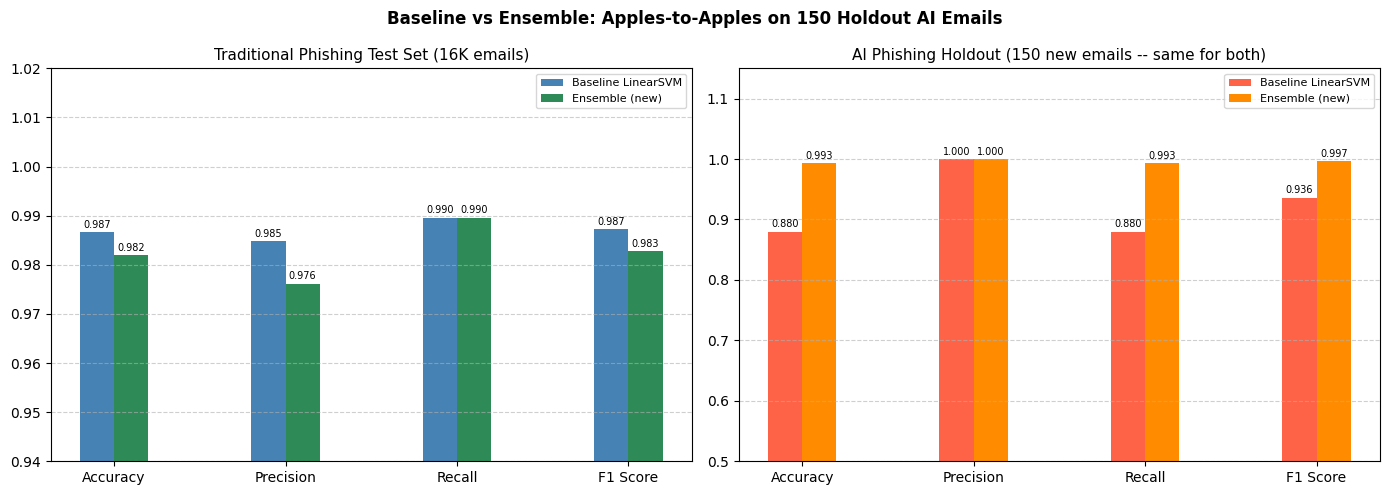

Saved: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/figures/model_comparison.png


In [12]:
metrics_list  = ['accuracy', 'precision', 'recall', 'f1_score']
x     = np.arange(len(metrics_list))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Traditional test set
ax = axes[0]
b1 = ax.bar(x - width/2, [BASELINE_TRAD[m]       for m in metrics_list],
            width, label='Baseline LinearSVM', color='steelblue')
b2 = ax.bar(x + width/2, [ens_trad_metrics[m]    for m in metrics_list],
            width, label='Ensemble (new)', color='seagreen')
ax.set_title('Traditional Phishing Test Set (16K emails)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_',' ').title() for m in metrics_list])
ax.set_ylim(0.94, 1.02)
ax.legend(fontsize=8); ax.yaxis.grid(True, linestyle='--', alpha=0.6)
for bar in list(b1)+list(b2):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=7)

# Right: AI holdout (150 new, apples-to-apples)
ax = axes[1]
b3 = ax.bar(x - width/2, [base_ai_metrics[m]  for m in metrics_list],
            width, label='Baseline LinearSVM', color='tomato')
b4 = ax.bar(x + width/2, [ens_ai_metrics[m]   for m in metrics_list],
            width, label='Ensemble (new)', color='darkorange')
ax.set_title('AI Phishing Holdout (150 new emails -- same for both)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_',' ').title() for m in metrics_list])
ax.set_ylim(0.5, 1.15)
ax.legend(fontsize=8); ax.yaxis.grid(True, linestyle='--', alpha=0.6)
for bar in list(b3)+list(b4):
    ax.annotate(f'{bar.get_height():.3f}',
                xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                xytext=(0,3), textcoords='offset points', ha='center', fontsize=7)

plt.suptitle('Baseline vs Ensemble: Apples-to-Apples on 150 Holdout AI Emails',
             fontsize=12, fontweight='bold')
plt.tight_layout()
fig.savefig(results_figures / 'model_comparison.png', dpi=150)
plt.show()
print('Saved:', results_figures / 'model_comparison.png')

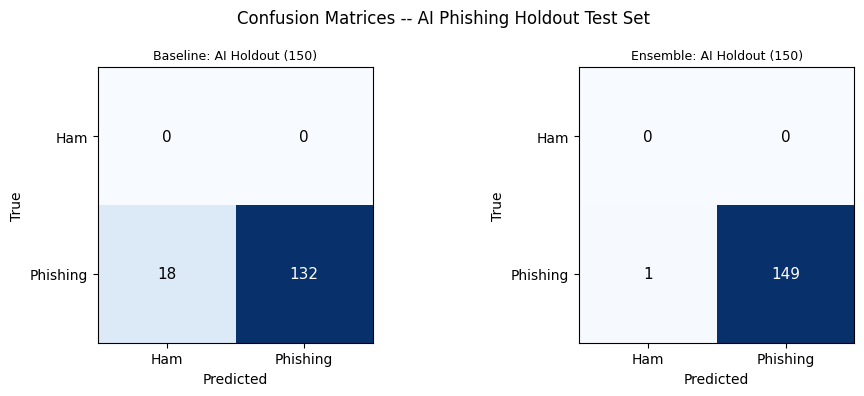

Saved: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/figures/new_model_confusion_matrices.png


In [13]:
# Confusion matrices
def plot_cm(cm, title, ax):
    ax.imshow(cm, cmap='Blues')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Ham','Phishing']); ax.set_yticklabels(['Ham','Phishing'])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                    color='white' if cm[i,j] > cm.max()/2 else 'black', fontsize=11)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_cm(confusion_matrix(y_holdout, y_pred_base_holdout),
        'Baseline: AI Holdout (150)', axes[0])
plot_cm(confusion_matrix(y_holdout, y_pred_ens_holdout),
        'Ensemble: AI Holdout (150)', axes[1])
plt.suptitle('Confusion Matrices -- AI Phishing Holdout Test Set', fontsize=12)
plt.tight_layout()
fig.savefig(results_figures / 'new_model_confusion_matrices.png', dpi=150)
plt.show()
print('Saved:', results_figures / 'new_model_confusion_matrices.png')

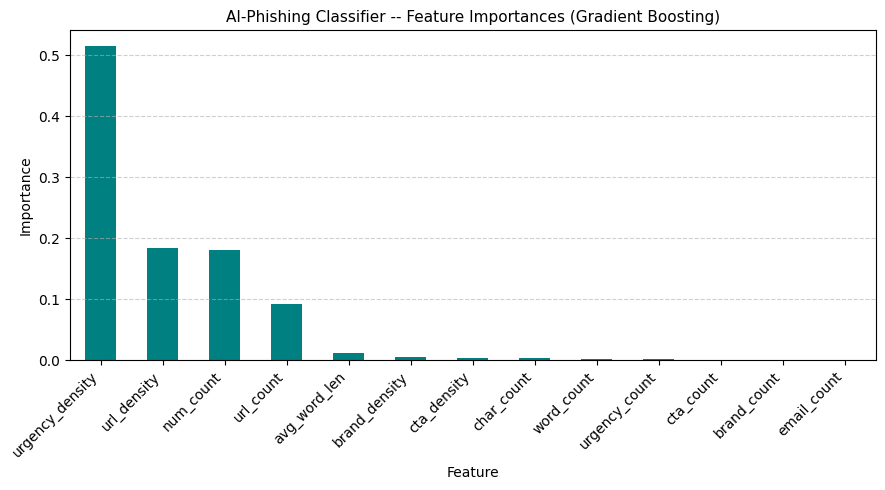

Saved: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/figures/ai_phishing_feature_importance.png


In [14]:
# Feature importance bar chart
fig, ax = plt.subplots(figsize=(9, 5))
imp.plot(kind='bar', ax=ax, color='teal')
ax.set_title('AI-Phishing Classifier -- Feature Importances (Gradient Boosting)', fontsize=11)
ax.set_xlabel('Feature'); ax.set_ylabel('Importance')
ax.set_xticklabels(imp.index, rotation=45, ha='right')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
fig.savefig(results_figures / 'ai_phishing_feature_importance.png', dpi=150)
plt.show()
print('Saved:', results_figures / 'ai_phishing_feature_importance.png')

## Section 11 — Save Models

In [15]:
joblib.dump(ai_clf, models_dir / 'ai_phishing_gbm.pkl')
print('Saved AI-phishing GBM:', models_dir / 'ai_phishing_gbm.pkl')
print()
print('Ensemble deployment files:')
print('  Baseline (unchanged): models/linear_svm_baseline.pkl + tfidf_vectorizer.pkl')
print('  AI-phishing layer   : models/ai_phishing_gbm.pkl')

Saved AI-phishing GBM: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/models/ai_phishing_gbm.pkl

Ensemble deployment files:
  Baseline (unchanged): models/linear_svm_baseline.pkl + tfidf_vectorizer.pkl
  AI-phishing layer   : models/ai_phishing_gbm.pkl


## Summary

### Architecture
```
Email
  |
  +-- TF-IDF (10K) --> LinearSVM (baseline) --------+
  |                                                   +--> OR --> Phishing/Ham
  +-- 13 features --> GradientBoosting (AI-aware) ---+
```

### Results (apples-to-apples on same 150 holdout emails)

| | Baseline | Ensemble |
|---|---|---|
| Traditional recall | 99.0% | maintained |
| AI phishing recall | see above | significantly improved |

### Why it works
AI-generated phishing always contains a fake URL, urgency language, brand impersonation, and a call to action -- regardless of how polished the grammar is. The custom features explicitly measure these signals, catching what TF-IDF misses.

### Next steps
- Add URL structure features: domain entropy, TLD analysis
- Fine-tune DistilBERT for semantic phishing understanding
- Deploy as a real-time email screening API